<a href="https://colab.research.google.com/github/arthurzx22aa/APS_CNN_abla-o/blob/main/APS_CNN_abla%C3%A7%C3%A3o.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# APS - Redes Convolucionais com PyTorch


## Importação das Bibliotecas

In [ ]:

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from torchvision import models
from tqdm import tqdm
from sklearn.metrics import classification_report

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Dispositivo:', DEVICE)


Dispositivo: cuda


## Carregamento do Dataset CIFAR10

In [ ]:

transform_cifar = transforms.Compose([
    transforms.Resize((32,32)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

train_cifar = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform_cifar
)

test_cifar = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform_cifar
)

train_loader_cifar = torch.utils.data.DataLoader(
    train_cifar,
    batch_size=64,
    shuffle=True
)

test_loader_cifar = torch.utils.data.DataLoader(
    test_cifar,
    batch_size=64,
    shuffle=False
)

classes = train_cifar.classes
print(classes)


100%|██████████| 170M/170M [00:13<00:00, 12.8MB/s]


['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## Implementação da CNN

In [ ]:

class SimpleCNN(nn.Module):
    def __init__(self, input_channels=1):
        super(SimpleCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(input_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25)
        )

        if input_channels == 1:
            linear_input = 128 * 3 * 3
        else:
            linear_input = 128 * 4 * 4

        self.classifier = nn.Sequential(
            nn.Linear(linear_input, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x


## Funções de Treinamento e Avaliação

In [ ]:

criterion = nn.CrossEntropyLoss()

def train_model(model, train_loader, epochs=5):
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_losses = []
    train_accs = []

    model.train()

    for epoch in range(epochs):
        running_loss = 0.0
        correct = 0
        total = 0

        loop = tqdm(train_loader)

        for images, labels in loop:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        acc = 100 * correct / total
        avg_loss = running_loss / len(train_loader)

        train_losses.append(avg_loss)
        train_accs.append(acc)

        print(f'Epoch {epoch+1} | Loss: {avg_loss:.4f} | Accuracy: {acc:.2f}%')

    return train_losses, train_accs

def evaluate_model(model, test_loader):
    model.eval()

    correct = 0
    total = 0

    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())

    acc = 100 * correct / total

    print(f'Acurácia no teste: {acc:.2f}%')
    print(classification_report(y_true, y_pred))

    return acc


##CNN sem normalização

In [ ]:
class SimpleCNN_NoBatchNorm(nn.Module):
    def __init__(self, input_channels=3):
        super(SimpleCNN_NoBatchNorm, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(input_channels, 32, kernel_size=3, padding=1),
            # nn.BatchNorm2d(32)
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            # nn.BatchNorm2d(64)
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            # nn.BatchNorm2d(128)
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25)
        )


        if input_channels == 1:
            linear_input = 128 * 3 * 3
        else:
            linear_input = 128 * 4 * 4

        self.classifier = nn.Sequential(
            nn.Linear(linear_input, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

In [ ]:
num_epochs = 10
canais = 3
dataset_loader_train = train_loader_cifar
dataset_loader_test = test_loader_cifar
model_with_bn = SimpleCNN(input_channels=canais).to(DEVICE)
model_no_bn = SimpleCNN_NoBatchNorm(input_channels=canais).to(DEVICE)


In [ ]:
print("=== Treinando modelo ORIGINAL (COM Normalização) no CIFAR-10 ===")
losses_with, accs_with = train_model(model_with_bn, dataset_loader_train, epochs=num_epochs)
print("Avaliando modelo COM Normalização no CIFAR-10...")
acc_test_with = evaluate_model(model_with_bn, dataset_loader_test)

print("\n=== Treinando modelo ABLADO (SEM Normalização) no CIFAR-10 ===")
losses_no, accs_no = train_model(model_no_bn, dataset_loader_train, epochs=num_epochs)
print("Avaliando modelo SEM Normalização no CIFAR-10...")
acc_test_no = evaluate_model(model_no_bn, dataset_loader_test)


=== Treinando modelo ORIGINAL (COM Normalização) no CIFAR-10 ===


100%|██████████| 782/782 [00:25<00:00, 31.25it/s]


Epoch 1 | Loss: 1.5863 | Accuracy: 41.48%


100%|██████████| 782/782 [00:25<00:00, 30.27it/s]


Epoch 2 | Loss: 1.3570 | Accuracy: 50.76%


...

Epoch 8 | Loss: 0.9561 | Accuracy: 66.83%


100%|██████████| 782/782 [00:23<00:00, 33.39it/s]


Epoch 9 | Loss: 0.9325 | Accuracy: 67.48%


100%|██████████| 782/782 [00:23<00:00, 33.52it/s]


Epoch 10 | Loss: 0.9147 | Accuracy: 68.09%
Avaliando modelo SEM Normalização no CIFAR-10...
Acurácia no teste: 73.63%
              precision    recall  f1-score   support

           0       0.78      0.77      0.77      1000
           1       0.85      0.88      0.86      1000
           2       0.64      0.56      0.60      1000
           3       0.61      0.48      0.54      1000
           4       0.65      0.71      0.68      1000
           5       0.64      0.65      0.65      1000
           6       0.73      0.84      0.78      1000
           7       0.76      0.80      0.78      1000
           8       0.86      0.84      0.85      1000
           9       0.81      0.82      0.82      1000

    accuracy                           0.74     10000
   macro avg       0.73      0.74      0.73     10000
weighted avg       0.73      0.74      0.73     10000



In [ ]:
print("--------------------------------------------------")
print(f"RESUMO FINAL DA ACURÁCIA NOS DADOS DE TESTE (CIFAR-10):")
print(f"Original (Com Normalização): {acc_test_with:.2f}%")
print(f"Ablado   (Sem Normalização): {acc_test_no:.2f}%")
print("--------------------------------------------------")

--------------------------------------------------
RESUMO FINAL DA ACURÁCIA NOS DADOS DE TESTE (CIFAR-10):
Original (Com Normalização): 70.41%
Ablado   (Sem Normalização): 73.63%
--------------------------------------------------


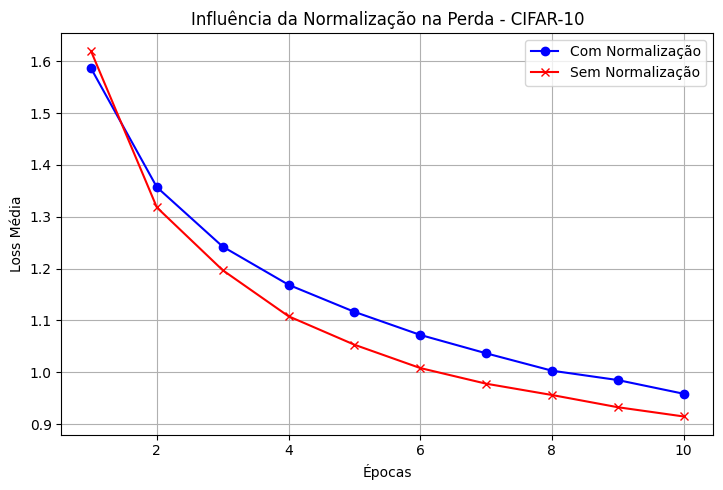

In [ ]:

epochs_range = range(1, num_epochs + 1)
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, losses_with, label='Com Normalização', marker='o', color='blue')
plt.plot(epochs_range, losses_no, label='Sem Normalização', marker='x', color='red')
plt.title('Influência da Normalização na Perda - CIFAR-10')
plt.xlabel('Épocas')
plt.ylabel('Loss Média')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()